# DodoGo RFM, Churn and Driver Positioning (NB03)

This notebook connects customer segmentation, churn risk and local supply gaps. The goal is to move from descriptive customer groups to practical operating actions: who should be retained, which customers need early attention, and where drivers should be positioned.

| Block | Method | Main result |
|---|---|---|
| RFM segmentation | Quintile scoring | Six customer segments for retention planning |
| Churn prediction | Gradient Boosting | Holdout AUC = 0.776; tuned CV AUC = 0.787 |
| Driver positioning | Demand x supply gap | Named undersupplied zones and peak-hour windows |


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

C = {'primary':'#1565C0','secondary':'#FF5722','success':'#4CAF50',
     'warning':'#FF9800','danger':'#E53935','purple':'#9C27B0','gray':'#9E9E9E'}
plt.rcParams.update({'figure.figsize':(14,8),'font.size':11,'figure.facecolor':'white',
    'axes.facecolor':'#FAFAFA','axes.grid':True,'grid.alpha':0.3,'figure.dpi':120})
print("Libraries loaded.")


Libraries loaded.


In [ ]:
# Load and prepare order data
df_new = pd.read_csv("../data/raw/orders_new_platform.csv", sep=";", encoding="windows-1251", low_memory=False)
df_new['created'] = pd.to_datetime(df_new['Дата создания'], format="%d.%m.%Y %H:%M", errors='coerce')
for col in ['Стоимость','Суммарное расстояние (км)']:
    df_new[col] = df_new[col].astype(str).str.replace(',','.').astype(float)
df_new.rename(columns={'Стоимость':'price','Суммарное расстояние (км)':'distance_km',
    'Текущий статус':'status','Тариф':'tariff','Способ заказа':'order_source',
    'Исполнитель':'driver','Телефон клиента':'client_phone','Адрес подачи':'pickup_address'}, inplace=True)
df_new['is_completed'] = df_new['status'].str.contains('Выполнен', na=False)
df_new['has_driver'] = df_new['driver'].notna() & (df_new['driver'].str.strip() != '')
df_new['hour'] = df_new['created'].dt.hour
df_new['day_of_week'] = df_new['created'].dt.dayofweek
df_new['date'] = pd.to_datetime(df_new['created'].dt.date)
df_new['month_num'] = df_new['created'].dt.month

comp = df_new[df_new['is_completed'] & (df_new['price']>0)].copy()
max_date = comp['date'].max()
print(f"Completed orders: {len(comp):,} ({comp['date'].min().date()} to {max_date.date()})")


Completed orders: 63,368 (2025-10-01 to 2026-04-07)


## 1. RFM Segmentation

RFM segmentation uses three simple behavioral signals: recency, frequency and monetary value. Recency shows how recently a customer ordered, frequency shows the strength of the habit, and monetary value is reported only as a relative engagement signal.

Each customer receives quintile scores from 1 to 5. The combined score is then mapped into six interpretable segments that can support different retention actions.


In [ ]:
# Customer-level RFM metrics
rfm = comp.groupby('client_phone').agg(
    recency=('date', lambda x: (max_date - x.max()).days),
    frequency=('price', 'count'),
    monetary=('price', 'sum')
)
rfm = rfm[rfm['frequency'] >= 1]

# Quintile scores
rfm['R_score'] = pd.qcut(rfm['recency'], 5, labels=[5,4,3,2,1]).astype(int)
rfm['F_score'] = pd.qcut(rfm['frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['M_score'] = pd.qcut(rfm['monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
rfm['RFM_score'] = rfm['R_score'] + rfm['F_score'] + rfm['M_score']

# Segment rules
def rfm_segment(row):
    if row['RFM_score'] >= 13: return 'Champions'
    if row['R_score'] >= 4 and row['F_score'] >= 3: return 'Loyal'
    if row['R_score'] >= 4 and row['F_score'] <= 2: return 'New / Promising'
    if row['R_score'] <= 2 and row['F_score'] >= 3: return 'At Risk'
    if row['R_score'] <= 2 and row['F_score'] <= 2: return 'Lost'
    return 'Regular'

rfm['segment'] = rfm.apply(rfm_segment, axis=1)
seg_order = ['Champions','Loyal','New / Promising','Regular','At Risk','Lost']
seg_colors = [C['success'],'#66BB6A',C['primary'],C['warning'],C['secondary'],C['danger']]
lost_mean = rfm.loc[rfm['segment']=='Lost', 'monetary'].mean()

print(f"Total customers: {len(rfm):,}")
print(f"{'Segment':20s} {'Count':>7s} {'%':>6s} {'Avg Freq':>10s} {'Spend x Lost':>13s} {'Avg Recency':>12s}")
print("="*72)
for seg in seg_order:
    s = rfm[rfm['segment']==seg]
    spend_index = s['monetary'].mean() / lost_mean if lost_mean else 0
    print(f"{seg:20s} {len(s):>7,} {len(s)/len(rfm)*100:>5.1f}% {s['frequency'].mean():>10.1f} "
          f"{spend_index:>12.1f}x {s['recency'].mean():>11.0f} days")

Total customers: 17,352

Segment                Count      %   Avg Freq  Spend x Lost  Avg Recency
Champions              3,234  18.6%       10.5          9.1x          27 days
Loyal                  2,186  12.6%        2.4          2.0x          28 days
New / Promising        2,037  11.7%        1.0          1.0x          27 days
Regular                2,997  17.3%        2.0          2.0x          77 days
At Risk                3,327  19.2%        3.7          3.3x         129 days
Lost                   3,571  20.6%        1.0          1.0x         133 days


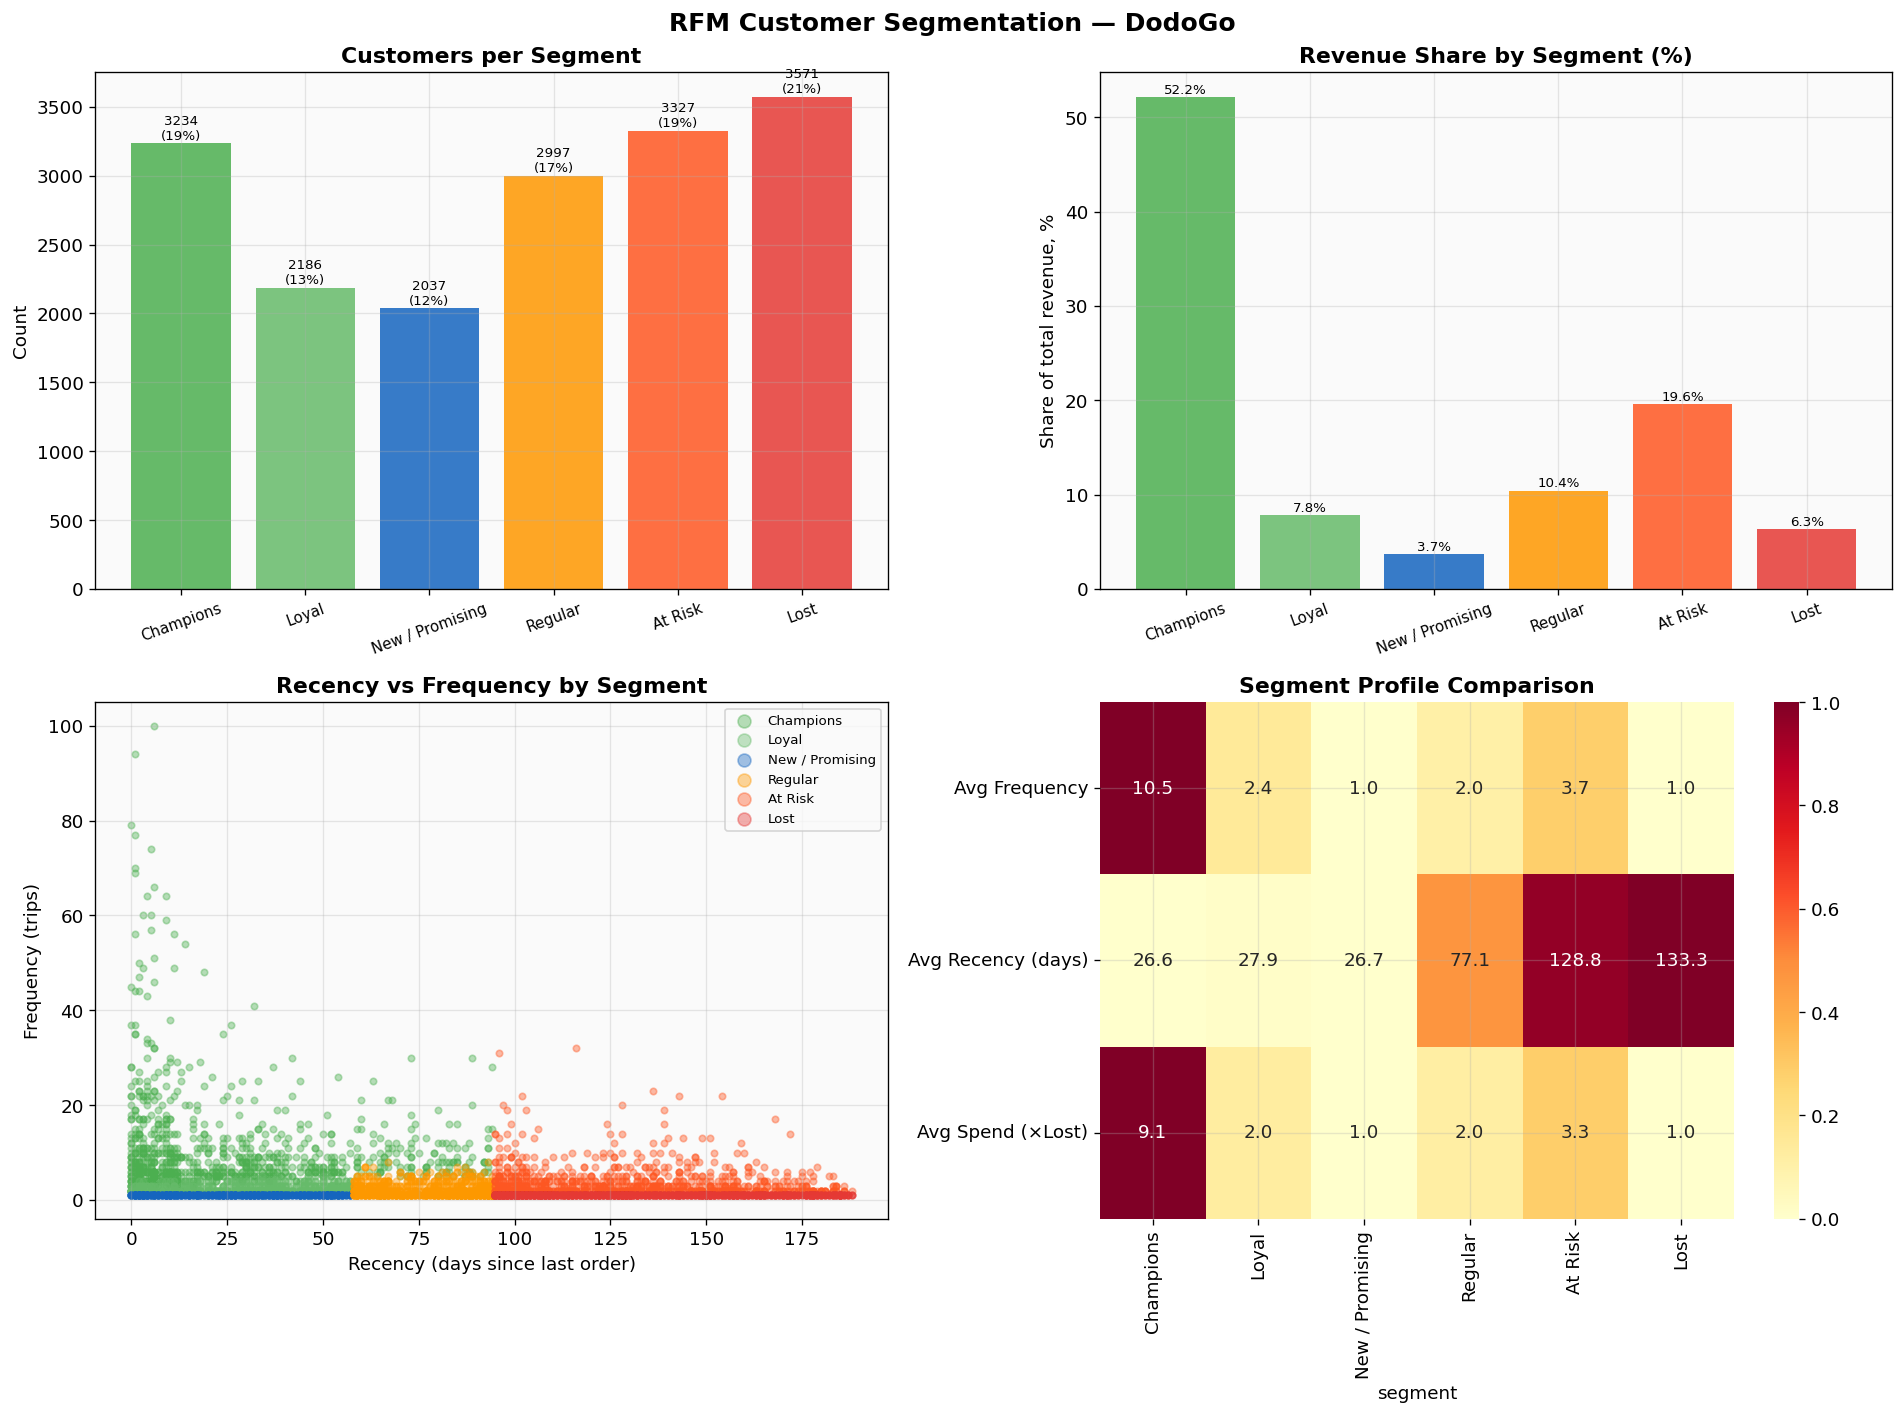

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('RFM Customer Segmentation - DodoGo', fontsize=15, fontweight='bold')

# Segment counts
ax = axes[0,0]
seg_counts = rfm['segment'].value_counts().reindex(seg_order).fillna(0)
bars = ax.bar(range(len(seg_counts)), seg_counts.values, color=seg_colors, alpha=0.85)
ax.set_xticks(range(len(seg_counts))); ax.set_xticklabels(seg_order, fontsize=9, rotation=20)
ax.set_title('Customers per Segment', fontweight='bold'); ax.set_ylabel('Count')
for b, v in zip(bars, seg_counts.values):
    ax.text(b.get_x()+b.get_width()/2, v+30, f'{v:.0f}\n({v/len(rfm)*100:.0f}%)', ha='center', fontsize=8)

# Relative value share
ax = axes[0,1]
seg_rev = rfm.groupby('segment')['monetary'].sum().reindex(seg_order).fillna(0)
seg_share = seg_rev / seg_rev.sum() * 100
bars = ax.bar(range(len(seg_share)), seg_share.values, color=seg_colors, alpha=0.85)
ax.set_xticks(range(len(seg_share))); ax.set_xticklabels(seg_order, fontsize=9, rotation=20)
ax.set_title('Value Share by Segment (%)', fontweight='bold')
ax.set_ylabel('Share of total value, %')
for b, v in zip(bars, seg_share.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f'{v:.1f}%', ha='center', fontsize=8)

# Recency-frequency map
ax = axes[1,0]
rfm_sample = rfm.sample(min(5000, len(rfm)), random_state=42)
for seg, color in zip(seg_order, seg_colors):
    mask = rfm_sample['segment'] == seg
    ax.scatter(rfm_sample.loc[mask,'recency'], rfm_sample.loc[mask,'frequency'],
               alpha=0.4, s=15, color=color, label=seg)
ax.set_title('Recency vs Frequency by Segment', fontweight='bold')
ax.set_xlabel('Recency (days since last order)'); ax.set_ylabel('Frequency (trips)')
ax.legend(fontsize=8, markerscale=2)

# Segment profile index
ax = axes[1,1]
seg_detail = rfm.groupby('segment').agg(
    avg_freq=('frequency','mean'), avg_recency=('recency','mean'),
    avg_revenue=('monetary','mean')).reindex(seg_order)
seg_detail['avg_revenue'] = seg_detail['avg_revenue'] / seg_detail.loc['Lost','avg_revenue']
seg_norm = (seg_detail - seg_detail.min()) / (seg_detail.max() - seg_detail.min())
sns.heatmap(seg_norm.T, ax=ax, cmap='YlOrRd', annot=seg_detail.T.round(1), fmt='.1f',
            yticklabels=['Avg Frequency','Avg Recency (days)','Avg Spend (x Lost)'])
ax.set_title('Segment Profile Comparison', fontweight='bold')

plt.tight_layout(); plt.show()


### RFM Segment Interpretation

| Segment | Size | Avg trips | Spend index | Recency | Strategy |
|---|---|---|---|---|---|
| Champions | about 3.2k (18.6%) | 10.5 | 9.1x | 27d | VIP treatment, referrals, early access |
| Loyal | about 2.2k (12.6%) | 2.4 | 2.0x | 28d | frequency incentives and upsell offers |
| New / Promising | about 2.0k (11.7%) | 1.0 | 1.0x | 27d | second-trip activation |
| Regular | about 3.0k (17.3%) | 2.0 | 2.0x | 77d | light re-engagement |
| At Risk | about 3.3k (19.2%) | 3.7 | 3.3x | 129d | win-back campaign and service-quality check |
| Lost | about 3.6k (20.6%) | 1.0 | 1.0x | 133d | low priority unless the user is local |

The main business segment is At Risk. These customers used the service more than casual users, but they have been inactive for a long time. This makes them more valuable for recovery than completely lost one-trip users.

Champions are the opposite case. They are already active and should be protected with reliability, priority communication and referral mechanics rather than aggressive discounts.


## 2. Churn Prediction

A customer is treated as churned if there was no order in the last 30 days. This is an operational definition rather than a permanent loss definition, because some customers may return later.

The model uses behavioral features such as trip count, average distance, booking rhythm, active days, tariff variety and cancellation history. The purpose is not only to predict churn, but also to identify which signals are useful for retention decisions.


In [ ]:
# Build churn dataset
CHURN_DAYS = 30

client_data = comp.groupby('client_phone').agg(
    last_order=('date', 'max'), first_order=('date', 'min'),
    total_trips=('price', 'count'), total_spent=('price', 'sum'),
    avg_price=('price', 'mean'),
    avg_distance=('distance_km', lambda x: x[x>0].mean()),
    avg_hour=('hour', 'mean'),
    weekend_ratio=('day_of_week', lambda x: (x>=5).mean()),
    unique_days=('date', 'nunique'),
    tariffs_used=('tariff', 'nunique')
)
client_data['tenure_days'] = (client_data['last_order'] - client_data['first_order']).dt.days
client_data['days_since_last'] = (max_date - client_data['last_order']).dt.days
client_data['orders_per_week'] = client_data['total_trips'] / (client_data['tenure_days']/7 + 1)

# Cancel rate
cancel_info = df_new.groupby('client_phone').agg(
    total_orders=('status','count'), cancelled=('is_completed', lambda x: (~x).sum()))
cancel_info['cancel_rate'] = cancel_info['cancelled'] / cancel_info['total_orders']
client_data = client_data.join(cancel_info[['cancel_rate']])

# Filter: 2+ trips, 14+ days on platform
client_data = client_data[(client_data['total_trips']>=2) & (client_data['tenure_days']>=14)].copy()
client_data['is_churned'] = (client_data['days_since_last'] > CHURN_DAYS).astype(int)
client_data = client_data.fillna(0)

print(f"Clients analyzed: {len(client_data):,}")
print(f"Churned (>{CHURN_DAYS} days inactive): {client_data['is_churned'].sum():,} ({client_data['is_churned'].mean()*100:.1f}%)")
print(f"Active: {(~client_data['is_churned'].astype(bool)).sum():,} ({(1-client_data['is_churned'].mean())*100:.1f}%)")

# Train model
features_churn = ['total_trips','avg_price','avg_distance','avg_hour','weekend_ratio',
                   'unique_days','tariffs_used','tenure_days','orders_per_week','cancel_rate']
X = client_data[features_churn]; y = client_data['is_churned']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

gb_churn = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
gb_churn.fit(X_tr, y_tr)
y_prob = gb_churn.predict_proba(X_te)[:,1]
auc = roc_auc_score(y_te, y_prob)

print(f"\nChurn Prediction AUC: {auc:.3f}")


Clients analyzed: 5,282
Churned (>30 days inactive): 2,944 (55.7%)
Active: 2,338 (44.3%)



Churn Prediction AUC: 0.776


### 2.1 Validation Strategy

The validation block checks whether the churn model is stable enough for business use. It combines stratified cross-validation, hyperparameter tuning, threshold sensitivity and a temporal split. The temporal split is especially important because DodoGo's customer base changed quickly during the observation period.


In [ ]:
import gc
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

# Stratified cross-validation
print('=' * 65)
print('5-FOLD STRATIFIED CROSS-VALIDATION - CHURN PREDICTION')
print('=' * 65)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores_cv = cross_val_score(gb_churn, X, y, cv=cv, scoring='roc_auc', n_jobs=1)
print(f"Gradient Boosting CV AUC: {scores_cv.mean():.4f} +/- {scores_cv.std():.4f}")
print(f"Fold scores: {', '.join(f'{s:.4f}' for s in scores_cv)}")

# Hyperparameter tuning
print(f"\n{'=' * 65}")
print('GRIDSEARCHCV - HYPERPARAMETER TUNING')
print('=' * 65)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_samples_leaf': [5, 10, 20]
}

grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid, cv=cv, scoring='roc_auc', n_jobs=1, refit=True
)
grid.fit(X, y)

print(f"Best parameters:")
for k, v in grid.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV AUC: {grid.best_score_:.4f} +/- {grid.cv_results_['std_test_score'][grid.best_index_]:.4f}")
print(f"Default AUC: {scores_cv.mean():.4f} to Tuned: {grid.best_score_:.4f} ({(grid.best_score_-scores_cv.mean())*100:+.2f} pp)")

# Churn threshold sensitivity
print(f"\n{'=' * 65}")
print('CHURN THRESHOLD SENSITIVITY ANALYSIS')
print('=' * 65)

thresholds = [15, 21, 30, 45, 60, 90]
print(f"{'Threshold':>12s} {'Churn %':>10s} {'N churned':>10s} {'CV AUC':>10s} {'+/- Std':>8s}")
print('-' * 55)

threshold_results = []
for t in thresholds:
    y_t = (client_data['days_since_last'] > t).astype(int)
    churn_pct = y_t.mean() * 100
    n_churned = y_t.sum()
    
    gb_t = GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42)
    scores_t = cross_val_score(gb_t, X, y_t, cv=cv, scoring='roc_auc', n_jobs=1)
    threshold_results.append({'threshold': t, 'auc': scores_t.mean(), 'std': scores_t.std(),
                              'churn_pct': churn_pct})
    print(f"{t:>10d}d {churn_pct:>9.1f}% {n_churned:>10,} {scores_t.mean():>10.4f} {scores_t.std():>7.4f}")

best_thresh = max(threshold_results, key=lambda x: x['auc'])
print(f"\nBest threshold: {best_thresh['threshold']}d (AUC={best_thresh['auc']:.4f})")
print(f"Current (30d): AUC={[r for r in threshold_results if r['threshold']==30][0]['auc']:.4f}")

# Temporal validation
print(f"\n{'=' * 65}")
print('TEMPORAL VALIDATION - Train on early users, test on recent users')
print('=' * 65)

# Split by first order date
median_first = client_data['first_order'].median()
train_mask = client_data['first_order'] < median_first
test_mask = ~train_mask

X_tr_t = X[train_mask]
y_tr_t = y[train_mask]
X_te_t = X[test_mask]
y_te_t = y[test_mask]

gb_temp = GradientBoostingClassifier(**grid.best_params_, random_state=42)
gb_temp.fit(X_tr_t, y_tr_t)
auc_temp = roc_auc_score(y_te_t, gb_temp.predict_proba(X_te_t)[:,1])

print(f"Train: {len(X_tr_t):,} (first order before {median_first.date()})")
print(f"Test:  {len(X_te_t):,} (first order after {median_first.date()})")
print(f"Temporal AUC: {auc_temp:.4f}")
print(f"CV AUC:       {grid.best_score_:.4f}")
diff = auc_temp - grid.best_score_
print(f"Difference:   {diff*100:+.2f} pp")

# Validation summary
print(f"\n{'=' * 65}")
print('CHURN MODEL VALIDATION SUMMARY')
print('=' * 65)
print(f"  Single holdout AUC:   {auc:.4f}")
print(f"  5-fold CV AUC:        {scores_cv.mean():.4f} +/- {scores_cv.std():.4f}")
print(f"  Tuned CV AUC:         {grid.best_score_:.4f} +/- {grid.cv_results_['std_test_score'][grid.best_index_]:.4f}")
print(f"  Temporal AUC:         {auc_temp:.4f}")
print(f"  Best churn threshold: {best_thresh['threshold']}d (AUC={best_thresh['auc']:.4f})")

_ = gc.collect()
print("Memory cleanup completed.")


5-FOLD STRATIFIED CROSS-VALIDATION - CHURN PREDICTION


Gradient Boosting CV AUC: 0.7757 +/- 0.0136
Fold scores: 0.7599, 0.7707, 0.7652, 0.7861, 0.7965

GRIDSEARCHCV - HYPERPARAMETER TUNING


Best parameters:
  learning_rate: 0.1
  max_depth: 3
  min_samples_leaf: 20
  n_estimators: 100
Best CV AUC: 0.7869 +/- 0.0103
Default AUC: 0.7757 to Tuned: 0.7869 (+1.12 pp)

CHURN THRESHOLD SENSITIVITY ANALYSIS
   Threshold    Churn %  N churned     CV AUC    +/- Std
-------------------------------------------------------


        15d      67.9%      3,586     0.7561  0.0110


        21d      62.9%      3,324     0.7623  0.0180


...

        45d      43.8%      2,313     0.7964  0.0147


        60d      35.0%      1,851     0.8100  0.0122


        90d      20.4%      1,077     0.8410  0.0105

Best threshold: 90d (AUC=0.8410)
Current (30d): AUC=0.7757

TEMPORAL VALIDATION - Train on early users, Test on recent users


Train: 2,629 (first order before 2025-11-18)
Test:  2,653 (first order after 2025-11-18)
Temporal AUC: 0.6434
CV AUC:       0.7869
Difference:   -14.35 pp

CHURN MODEL VALIDATION SUMMARY
  Single holdout AUC:   0.7759
  5-fold CV AUC:        0.7757 +/- 0.0136
  Tuned CV AUC:         0.7869 +/- 0.0103
  Temporal AUC:         0.6434
  Best churn threshold: 90d (AUC=0.8410)


Memory cleanup completed.


### 2.2 Extended Feature Set

The baseline model describes the average customer. The extended feature set adds trajectory variables that better reflect whether the relationship is improving or weakening.

Two planned variables are not used here. Wait time is not available for the new platform, and bonus balance is too sparse to be reliable. The final extension therefore uses five history-based variables on the same customer sample.

| Feature | Definition | Interpretation |
|---|---|---|
| trips_slope_recent | linear slope of weekly trip counts | increasing or decreasing habit |
| last_order_cancelled | most recent attempt was cancelled | negative last experience |
| max_gap_days | maximum gap between completed trips | habit interruption |
| unique_areas | number of distinct pickup areas | breadth of use |
| recent_cancel_ratio | cancellation share in last three attempts | recent service friction |

The tuned parameters from the validation block are kept fixed, so the AUC change reflects the added features rather than a different model setup.


Sample:           5,282 rows (same as baseline)
Baseline feat:    10
Extended feat:    15  (+5 new)



CUSTOMER CHURN - BASELINE vs EXTENDED (5-fold CV, same sample)
Baseline (10 feat):  AUC = 0.7869 +/- 0.0103  (folds: 0.7813, 0.7782, 0.7768, 0.7949, 0.8031)
Extended (15 feat):  AUC = 0.7983 +/- 0.0117  (folds: 0.7963, 0.7870, 0.7847, 0.8111, 0.8127)
Delta:                +1.15 pp  (per-fold: +1.50, +0.88, +0.79, +1.62, +0.96 pp)


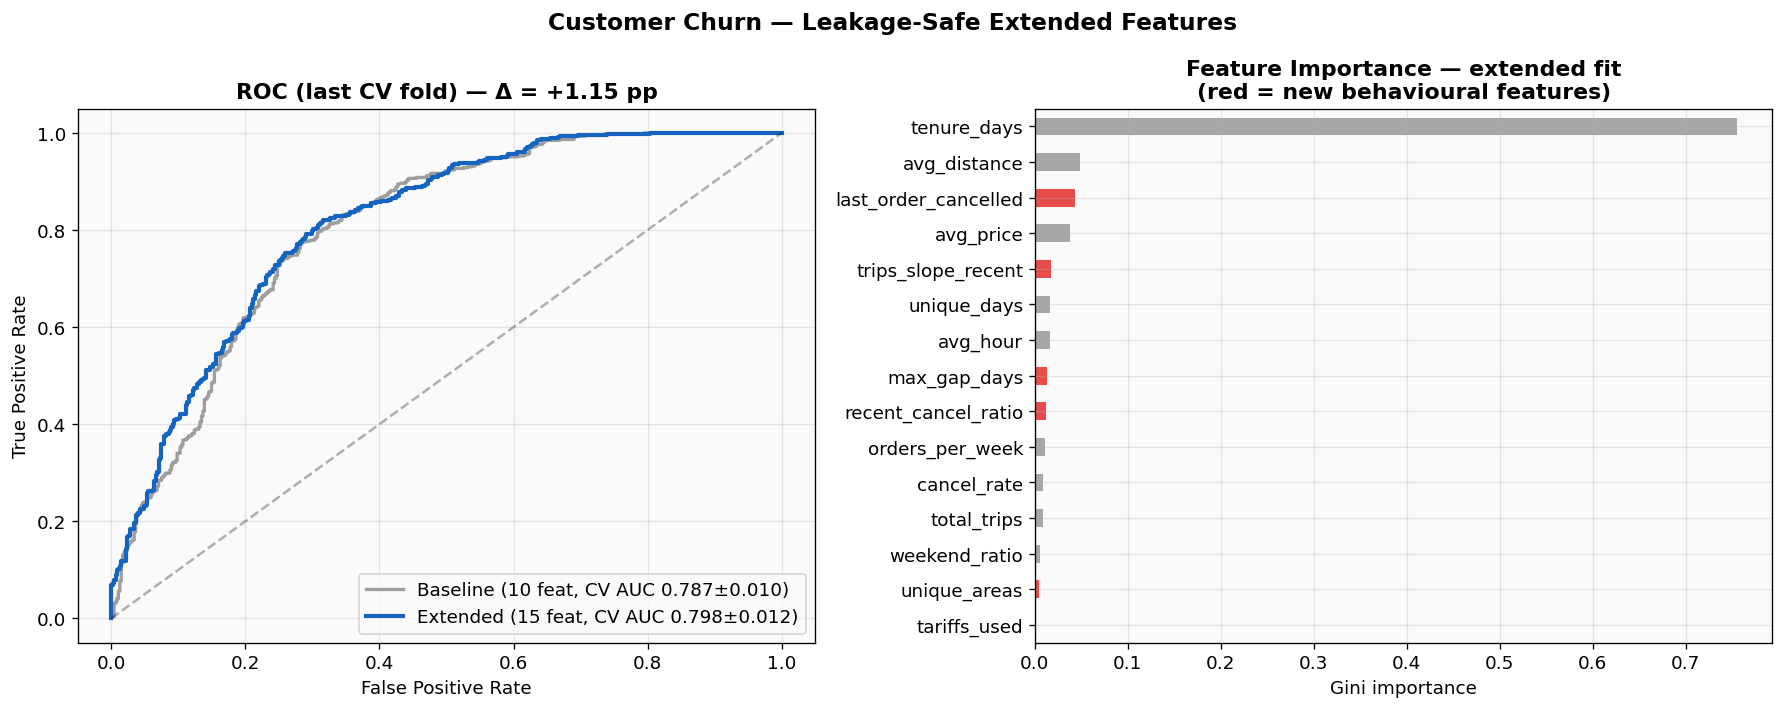


Feature importance (extended fit, sorted):
  tenure_days               0.7555
  avg_distance              0.0482
  last_order_cancelled      0.0434  [NEW]
  avg_price                 0.0378
  trips_slope_recent        0.0177  [NEW]
  unique_days               0.0168
  avg_hour                  0.0163
  max_gap_days              0.0128  [NEW]
  recent_cancel_ratio       0.0121  [NEW]
  orders_per_week           0.0108
  cancel_rate               0.0086
  total_trips               0.0086
  weekend_ratio             0.0059
  unique_areas              0.0041  [NEW]
  tariffs_used              0.0016


Memory cleanup completed.


In [ ]:
# Extended churn feature set
from sklearn.metrics import roc_curve

# Pickup-area extractor
def _area(addr):
    if pd.isna(addr): return 'Other'
    s = str(addr).lower()
    for a, kws in {'Grand Baie':['grand baie','grand bay'],'Port Louis':['port louis'],
        'Flic en Flac':['flic en flac'],'Quatre Bornes':['quatre bornes'],
        'Curepipe':['curepipe'],'Airport':['airport','ssr'],
        'Trianon/Moka':['trianon','moka','bagatelle'],'Pamplemousses':['pamplemousses'],
        'Vacoas':['vacoas','phoenix'],'Beau Bassin':['beau bassin','rose hill'],
        'Trou aux Biches':['trou aux biches'],'Tamarin':['tamarin'],
        'Cap Malheureux':['cap malheureux'],'Mahebourg':['mahebourg']}.items():
        for kw in kws:
            if kw in s: return a
    return 'Other'

df_new['area'] = df_new['pickup_address'].apply(_area)
comp_ext = df_new[df_new['is_completed'] & (df_new['price'] > 0)].copy()

# Baseline customer sample
client_phones = client_data.index

def _slope(dates):
    if len(dates) < 2: return 0.0
    d0, d1 = dates.min(), dates.max()
    weeks = max(1, int(np.ceil((d1 - d0).days / 7)) + 1)
    if weeks < 3: return 0.0
    bins = pd.cut((dates - d0).dt.days, bins=np.arange(0, weeks * 7 + 1, 7), right=False,
                  labels=range(weeks))
    counts = bins.value_counts().reindex(range(weeks), fill_value=0).astype(float).values
    x = np.arange(weeks)
    return float(np.polyfit(x, counts, 1)[0])

slopes = comp_ext[comp_ext['client_phone'].isin(client_phones)] \
    .groupby('client_phone')['date'].apply(_slope)

last_attempt = df_new[df_new['client_phone'].isin(client_phones)] \
    .sort_values('created').groupby('client_phone').tail(1) \
    .set_index('client_phone')
last_cancelled = (~last_attempt['is_completed']).astype(int)

def _maxgap(dates):
    ds = dates.sort_values()
    if len(ds) < 2: return 0
    return int(ds.diff().dt.days.max())
max_gap = comp_ext[comp_ext['client_phone'].isin(client_phones)] \
    .groupby('client_phone')['date'].apply(_maxgap)

uniq_areas = comp_ext[comp_ext['client_phone'].isin(client_phones)] \
    .groupby('client_phone')['area'].nunique()

def _recent_cx(g):
    tail = g.sort_values('created').tail(3)
    if len(tail) == 0: return 0.0
    return float((~tail['is_completed']).mean())
recent_cx = df_new[df_new['client_phone'].isin(client_phones)] \
    .groupby('client_phone').apply(_recent_cx)

# Join trajectory features
client_ext = client_data.copy()
client_ext['trips_slope_recent']  = slopes.reindex(client_ext.index).fillna(0)
client_ext['last_order_cancelled'] = last_cancelled.reindex(client_ext.index).fillna(0).astype(int)
client_ext['max_gap_days']         = max_gap.reindex(client_ext.index).fillna(0).astype(int)
client_ext['unique_areas']         = uniq_areas.reindex(client_ext.index).fillna(1).astype(int)
client_ext['recent_cancel_ratio']  = recent_cx.reindex(client_ext.index).fillna(0)

# Feature matrices
feat_base = features_churn
feat_new  = ['trips_slope_recent', 'last_order_cancelled', 'max_gap_days',
             'unique_areas', 'recent_cancel_ratio']
feat_ext  = feat_base + feat_new

X_base = client_ext[feat_base]
X_ext  = client_ext[feat_ext]
y_     = client_ext['is_churned']

print(f"Sample:           {len(client_ext):,} rows (same as baseline)")
print(f"Baseline feat:    {len(feat_base)}")
print(f"Extended feat:    {len(feat_ext)}  (+{len(feat_new)} new)")

# Fixed-parameter cross-validation
tuned = dict(learning_rate=0.1, max_depth=3, min_samples_leaf=20,
             n_estimators=100, random_state=42)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def _cv_auc(Xm, ym):
    aucs = []
    for tr, te in cv5.split(Xm, ym):
        m = GradientBoostingClassifier(**tuned)
        m.fit(Xm.iloc[tr], ym.iloc[tr])
        aucs.append(roc_auc_score(ym.iloc[te], m.predict_proba(Xm.iloc[te])[:, 1]))
    return np.array(aucs)

aucs_base = _cv_auc(X_base, y_)
aucs_ext  = _cv_auc(X_ext,  y_)

print()
print('=' * 65)
print('CUSTOMER CHURN - BASELINE vs EXTENDED (5-fold CV, same sample)')
print('=' * 65)
print(f"Baseline ({len(feat_base)} feat):  AUC = {aucs_base.mean():.4f} +/- {aucs_base.std():.4f}  "
      f"(folds: {', '.join(f'{a:.4f}' for a in aucs_base)})")
print(f"Extended ({len(feat_ext)} feat):  AUC = {aucs_ext.mean():.4f} +/- {aucs_ext.std():.4f}  "
      f"(folds: {', '.join(f'{a:.4f}' for a in aucs_ext)})")
delta = aucs_ext.mean() - aucs_base.mean()
per_fold = [(e - b) * 100 for b, e in zip(aucs_base, aucs_ext)]
print(f"Delta:                +{delta*100:.2f} pp  "
      f"(per-fold: {', '.join(f'{d:+.2f}' for d in per_fold)} pp)")

# Full-fit importances and ROC
m_ext_full  = GradientBoostingClassifier(**tuned).fit(X_ext, y_)
last_tr, last_te = list(cv5.split(X_ext, y_))[-1]
fpr_b, tpr_b, _ = roc_curve(y_.iloc[last_te],
    GradientBoostingClassifier(**tuned).fit(X_base.iloc[last_tr], y_.iloc[last_tr])
      .predict_proba(X_base.iloc[last_te])[:, 1])
fpr_e, tpr_e, _ = roc_curve(y_.iloc[last_te],
    GradientBoostingClassifier(**tuned).fit(X_ext.iloc[last_tr], y_.iloc[last_tr])
      .predict_proba(X_ext.iloc[last_te])[:, 1])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Customer Churn - Leakage-Safe Extended Features', fontsize=14, fontweight='bold')

ax = axes[0]
ax.plot(fpr_b, tpr_b, color=C['gray'], lw=2,
        label=f'Baseline (10 feat, CV AUC {aucs_base.mean():.3f}+/-{aucs_base.std():.3f})')
ax.plot(fpr_e, tpr_e, color=C['primary'], lw=2.5,
        label=f'Extended (15 feat, CV AUC {aucs_ext.mean():.3f}+/-{aucs_ext.std():.3f})')
ax.plot([0, 1], [0, 1], '--', color='black', alpha=0.3)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC (last CV fold): delta = +{delta*100:.2f} pp', fontweight='bold')
ax.legend(loc='lower right')

ax = axes[1]
imp = pd.Series(m_ext_full.feature_importances_, index=feat_ext).sort_values()
new_set = set(feat_new)
colors_imp = [C['danger'] if f in new_set else C['gray'] for f in imp.index]
imp.plot(kind='barh', ax=ax, color=colors_imp, alpha=0.9)
ax.set_title('Feature Importance - extended fit\n(red = new behavioral features)', fontweight='bold')
ax.set_xlabel('Gini importance')

plt.tight_layout()
plt.savefig('figures/fig_churn_extended_features.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('Feature importance (extended fit, sorted):')
for f, v in imp.sort_values(ascending=False).items():
    tag = '  [NEW]' if f in new_set else ''
    print(f"  {f:25s} {v:.4f}{tag}")

_ = gc.collect()
print("Memory cleanup completed.")


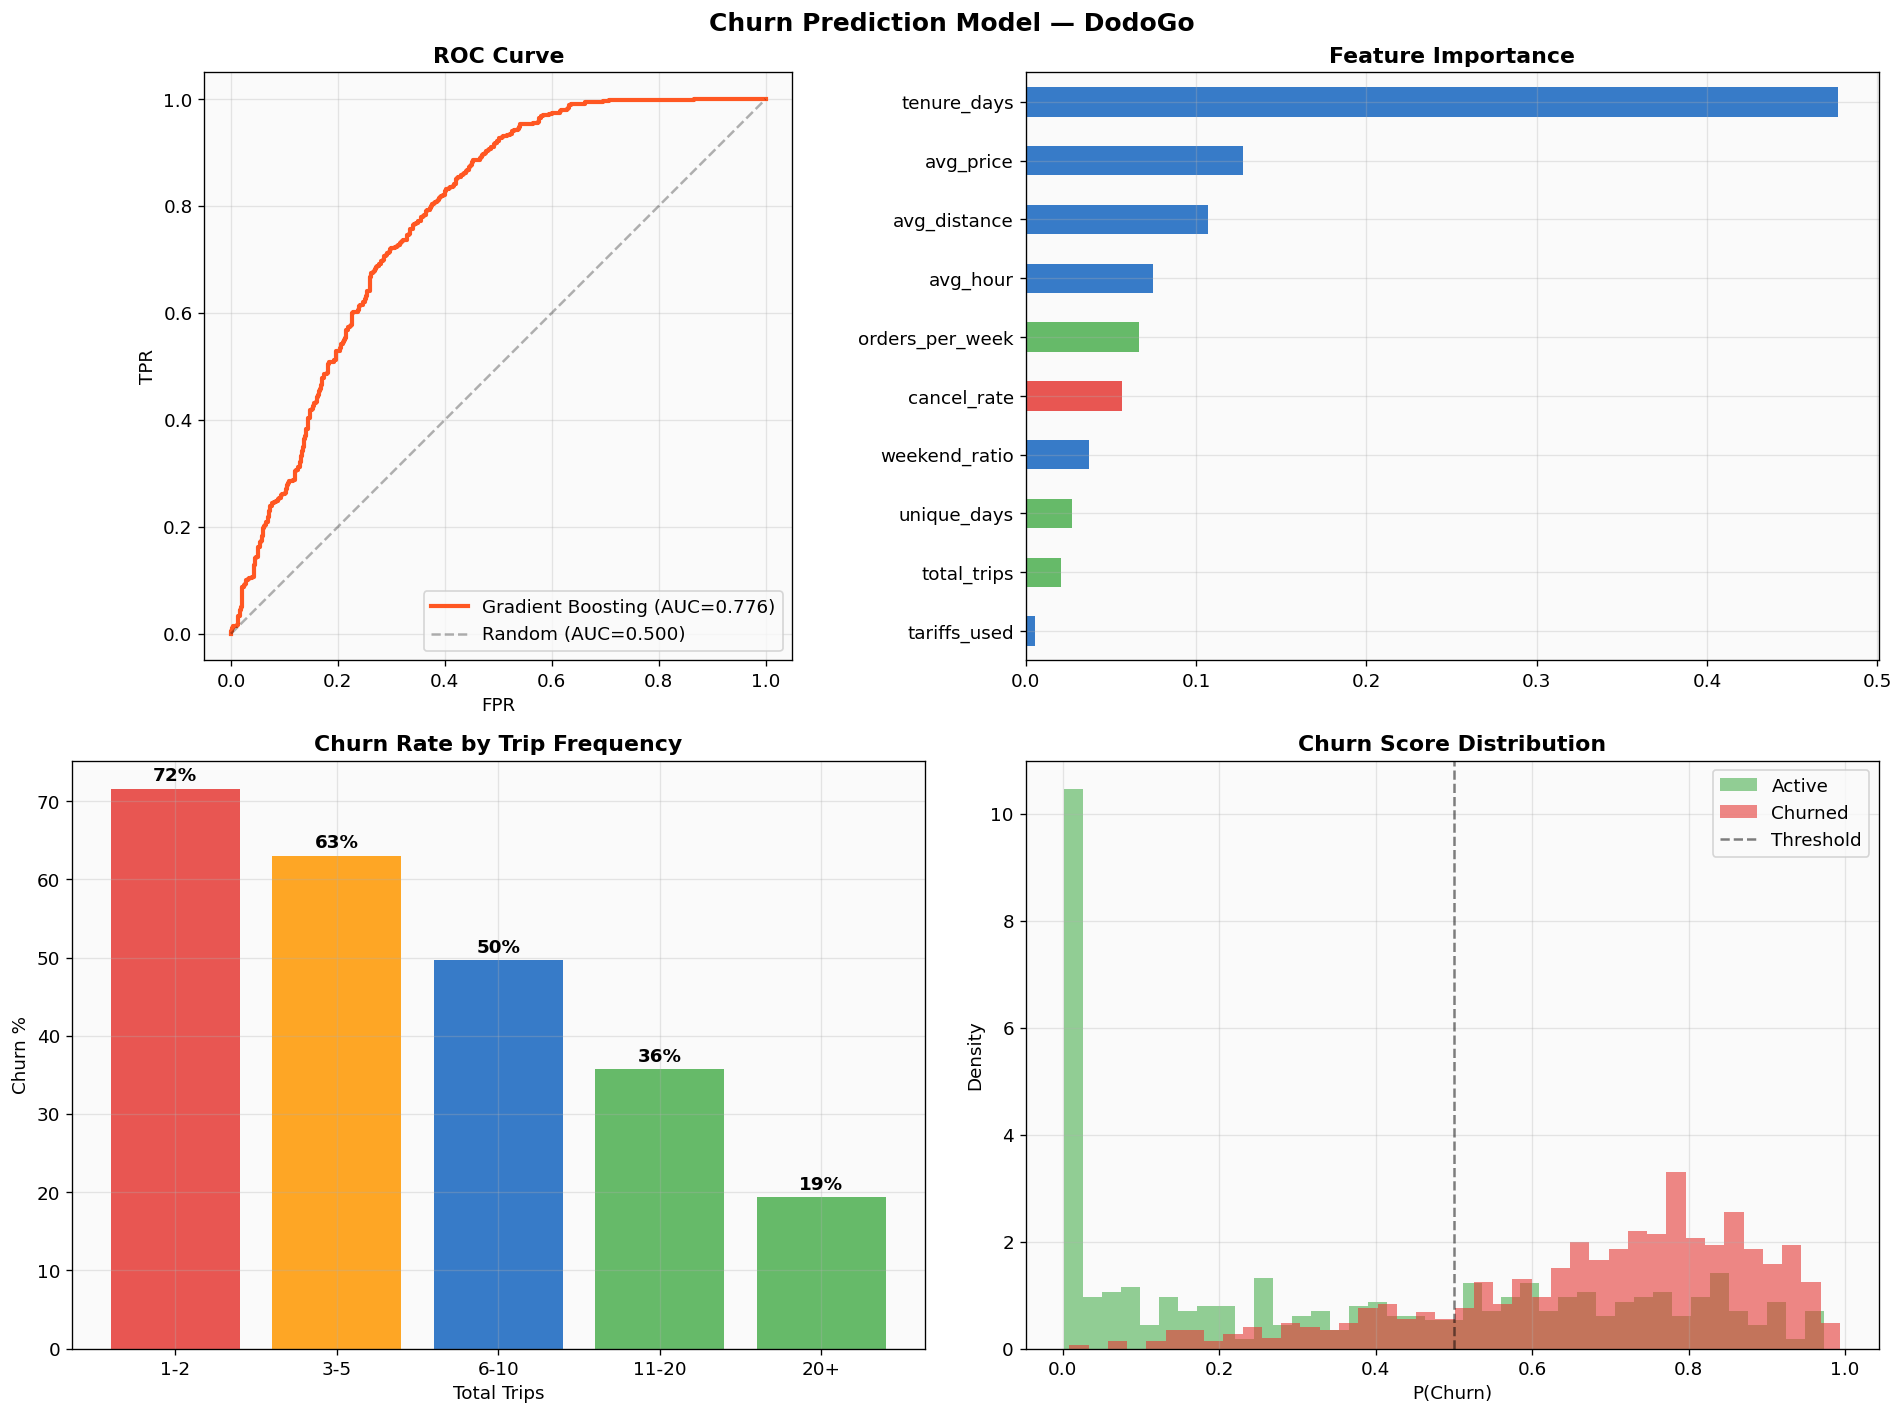

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Churn Prediction Model - DodoGo', fontsize=15, fontweight='bold')

# ROC
ax = axes[0,0]
fpr, tpr, _ = roc_curve(y_te, y_prob)
ax.plot(fpr, tpr, color=C['secondary'], lw=2.5, label=f'Gradient Boosting (AUC={auc:.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.3, label='Random (AUC=0.500)')
ax.set_title('ROC Curve', fontweight='bold')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR'); ax.legend(fontsize=11); ax.set_aspect('equal')

# Feature importance
ax = axes[0,1]
imp = pd.Series(gb_churn.feature_importances_, index=features_churn).sort_values()
colors_imp = [C['danger'] if f=='cancel_rate' else C['success'] if f in ['total_trips','orders_per_week','unique_days']
              else C['primary'] for f in imp.index]
imp.plot(kind='barh', ax=ax, color=colors_imp, alpha=0.85)
ax.set_title('Feature Importance', fontweight='bold')

# Churn by frequency
ax = axes[1,0]
client_data['freq_bucket'] = pd.cut(client_data['total_trips'], bins=[0,2,5,10,20,1000],
                                      labels=['1-2','3-5','6-10','11-20','20+'])
churn_freq = client_data.groupby('freq_bucket')['is_churned'].mean()*100
bars = ax.bar(range(len(churn_freq)), churn_freq.values,
              color=[C['danger'],C['warning'],C['primary'],C['success'],C['success']], alpha=0.85)
ax.set_xticks(range(len(churn_freq))); ax.set_xticklabels(churn_freq.index)
ax.set_title('Churn Rate by Trip Frequency', fontweight='bold')
ax.set_ylabel('Churn %'); ax.set_xlabel('Total Trips')
for b, v in zip(bars, churn_freq.values):
    ax.text(b.get_x()+b.get_width()/2, v+1, f'{v:.0f}%', ha='center', fontweight='bold')

# Score distribution
ax = axes[1,1]
ax.hist(y_prob[y_te==0], bins=40, alpha=0.6, color=C['success'], label='Active', density=True)
ax.hist(y_prob[y_te==1], bins=40, alpha=0.6, color=C['danger'], label='Churned', density=True)
ax.axvline(0.5, color='k', ls='--', alpha=0.5, label='Threshold')
ax.set_title('Churn Score Distribution', fontweight='bold')
ax.set_xlabel('P(Churn)'); ax.set_ylabel('Density'); ax.legend()

plt.tight_layout(); plt.show()


### Churn Prediction Results

The holdout model reaches AUC = 0.776, and the tuned cross-validation result reaches AUC = 0.787. This is useful for prioritizing retention actions, although the temporal validation is weaker, which means the model should be monitored as customer behavior changes.

The strongest feature is tenure. Newer customers are more fragile, while customers with a longer relationship tend to be more stable. Distance and price-related signals are also important, but they should be interpreted carefully because tourists and airport trips naturally behave differently from local repeated usage.

The frequency curve shows a clear activation problem. One- and two-trip users churn at a much higher rate than customers who have already built a habit. DodoGo should therefore focus retention messages and small incentives around the third to fifth completed trip, especially for local customers.


## 3. Driver Positioning and Demand Hot Spots

A completed ride requires both demand and available drivers. When demand is high but supply is weak, the platform loses orders through no-driver and long-wait outcomes.

The positioning block builds an area by hour by weekday matrix and overlays observed supply failures. The priority score gives more weight to cells where demand is meaningful and failure rates are high.

`Priority = Demand x (1 + Failure Rate)`


In [ ]:
def extract_area(addr):
    if pd.isna(addr): return 'Other'
    addr = str(addr).lower()
    for a, kws in {'Grand Baie':['grand baie','grand bay'],'Port Louis':['port louis'],
        'Flic en Flac':['flic en flac'],'Quatre Bornes':['quatre bornes'],
        'Curepipe':['curepipe'],'Airport':['airport','ssr'],
        'Trianon/Moka':['trianon','moka','bagatelle'],'Pamplemousses':['pamplemousses'],
        'Vacoas':['vacoas','phoenix'],'Beau Bassin':['beau bassin','rose hill'],
        'Trou aux Biches':['trou aux biches'],'Tamarin':['tamarin'],
        'Cap Malheureux':['cap malheureux'],'Mahebourg':['mahebourg']}.items():
        for kw in kws:
            if kw in addr: return a
    return 'Other'

comp['area'] = comp['pickup_address'].apply(extract_area)
df_new['area'] = df_new['pickup_address'].apply(extract_area)

# Demand matrix
n_weeks = max(1, (comp['date'].max() - comp['date'].min()).days / 7)
demand = comp.groupby(['area','hour','day_of_week']).size().reset_index(name='orders')
demand['weekly_orders'] = demand['orders'] / n_weeks

# Supply failures
supply_fail = df_new[df_new['status'].isin(['Водитель не найден','Исполнитель не найден','Слишком долго ждать'])]
fail_matrix = supply_fail.groupby(['area','hour','day_of_week']).size().reset_index(name='failures')

# Priority score
pos = demand.merge(fail_matrix, on=['area','hour','day_of_week'], how='left')
pos['failures'] = pos['failures'].fillna(0)
pos['failure_rate'] = pos['failures'] / (pos['orders'] + pos['failures'])
pos['priority_score'] = pos['weekly_orders'] * (1 + pos['failure_rate'])

# Area summary
area_rank = pos.groupby('area').agg(
    weekly_demand=('weekly_orders','sum'),
    avg_failure=('failure_rate','mean'),
    peak_hour=('weekly_orders', lambda x: pos.loc[x.idxmax(),'hour'])
).sort_values('weekly_demand', ascending=False)

# Top-area output
print(f"{'Area':20s} {'Demand/wk':>10s} {'Fail Rate':>10s} {'Peak Hour':>10s}")
print("="*55)
for area, row in area_rank.head(12).iterrows():
    print(f"{area:20s} {row['weekly_demand']:>10.0f} {row['avg_failure']*100:>9.1f}% {int(row['peak_hour']):>9d}:00")


Area                  Demand/wk  Fail Rate  Peak Hour
Other                       591      34.8%        16:00
Grand Baie                  360      18.1%        20:00
Quatre Bornes               265      21.1%        19:00
Port Louis                  238      25.5%        16:00
Vacoas                      179      28.2%         8:00
Trianon/Moka                174      17.8%        17:00
Beau Bassin                 142      25.5%        13:00
Flic en Flac                119      31.6%        10:00
Pamplemousses               118      24.9%        12:00
Curepipe                     81      23.9%        18:00
Cap Malheureux               34      16.9%        22:00
Tamarin                      30      33.9%        16:00


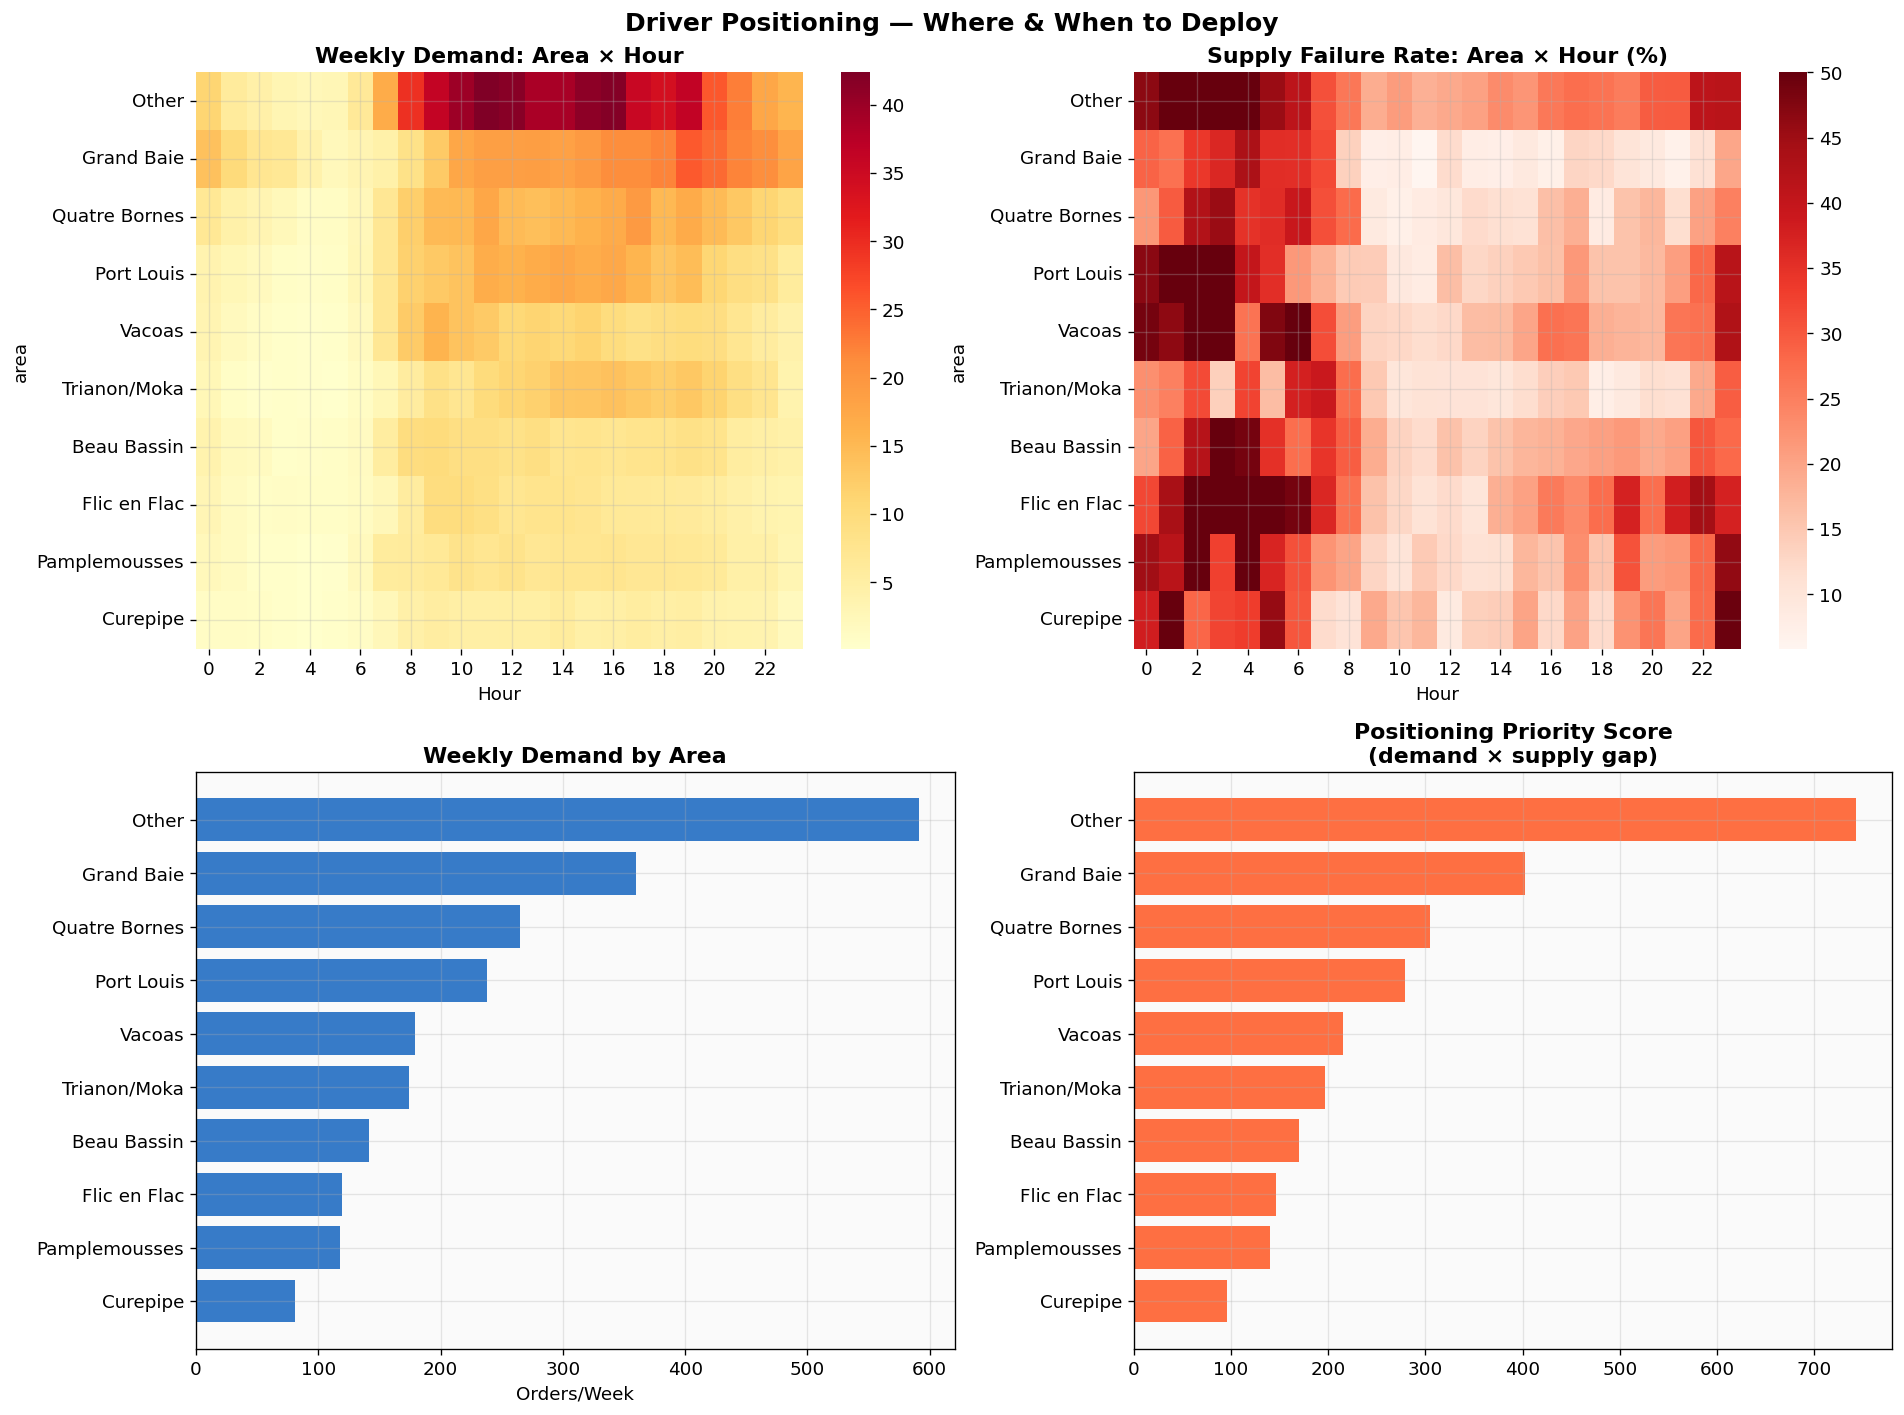


=== DRIVER POSITIONING RECOMMENDATIONS ===

Sat:
  - Other                at 16:00 (demand=8.0/wk, failures=33%)
  - Other                at 19:00 (demand=7.9/wk, failures=27%)
  - Other                at 17:00 (demand=7.1/wk, failures=31%)
  - Other                at 18:00 (demand=7.6/wk, failures=22%)
  - Other                at 15:00 (demand=7.1/wk, failures=21%)

Sun:
  - Other                at 11:00 (demand=6.6/wk, failures=26%)
  - Other                at 15:00 (demand=5.9/wk, failures=31%)
  - Other                at 16:00 (demand=5.3/wk, failures=33%)
  - Other                at 12:00 (demand=5.6/wk, failures=24%)
  - Other                at 17:00 (demand=5.3/wk, failures=30%)

Fri:
  - Other                at 16:00 (demand=6.4/wk, failures=26%)
  - Other                at 15:00 (demand=6.4/wk, failures=24%)
  - Other                at 12:00 (demand=5.8/wk, failures=25%)
  - Other                at 11:00 (demand=5.8/wk, failures=20%)
  - Other                at 18:00 (demand=

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Driver Positioning - Where and When to Deploy', fontsize=15, fontweight='bold')

# Top areas
top_areas = area_rank.head(10).index.tolist()

# Demand heatmap
ax = axes[0,0]
hm = pos[pos['area'].isin(top_areas)].groupby(['area','hour'])['weekly_orders'].sum().unstack(fill_value=0)
hm = hm.reindex(top_areas)
sns.heatmap(hm, ax=ax, cmap='YlOrRd', xticklabels=2)
ax.set_title('Weekly Demand: Area x Hour', fontweight='bold'); ax.set_xlabel('Hour')

# Failure-rate heatmap
ax = axes[0,1]
hm_f = pos[pos['area'].isin(top_areas)].groupby(['area','hour'])['failure_rate'].mean().unstack(fill_value=0)
hm_f = hm_f.reindex(top_areas)
sns.heatmap(hm_f*100, ax=ax, cmap='Reds', xticklabels=2, vmax=50)
ax.set_title('Supply Failure Rate: Area x Hour (%)', fontweight='bold'); ax.set_xlabel('Hour')

# Area ranking
ax = axes[1,0]
ar = area_rank.head(10).sort_values('weekly_demand')
ax.barh(ar.index, ar['weekly_demand'], color=C['primary'], alpha=0.85)
ax.set_title('Weekly Demand by Area', fontweight='bold'); ax.set_xlabel('Orders/Week')

# Priority score
ax = axes[1,1]
ps = pos.groupby('area')['priority_score'].sum().nlargest(10).sort_values()
ax.barh(ps.index, ps.values, color=C['secondary'], alpha=0.85)
ax.set_title('Positioning Priority Score\n(demand x supply gap)', fontweight='bold')

plt.tight_layout(); plt.show()

# Day-specific recommendations
print("\n=== DRIVER POSITIONING RECOMMENDATIONS ===")
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
for d in [5,6,4]:  # Sat, Sun, Fri
    top_d = pos[pos['day_of_week']==d].nlargest(5, 'priority_score')
    print(f"\n{days[d]}:")
    for _, r in top_d.iterrows():
        print(f"  - {r['area']:20s} at {int(r['hour']):02d}:00 "
              f"(demand={r['weekly_orders']:.1f}/wk, failures={r['failure_rate']*100:.0f}%)")


### Positioning Interpretation

The named-area results point to different operating problems. Grand Baie has the strongest demand and is relatively well served, while Flic en Flac and Vacoas show weaker supply conditions despite meaningful demand. Tamarin also has a high failure rate, but the absolute demand base is smaller.

The large `Other` category is a limitation of address parsing. It likely combines smaller towns, rural trips and addresses that do not match the simple keyword rules. For operational dispatching, this category should be reviewed with a more detailed geocoding layer before drivers are moved there.

Practical actions should therefore focus on named zones first: reinforce Saturday afternoon and evening coverage, test early-shift incentives around Flic en Flac, and monitor late-evening demand around Port Louis and tourist areas.


## 4. Notebook Summary

| Block | Method | Metric | Finding |
|---|---|---|---|
| RFM | Quintile scoring | Six segments | At Risk and Champions require different retention logic |
| Churn | Gradient Boosting | AUC 0.776 holdout, 0.787 tuned CV | Tenure and early usage intensity are the main signals |
| Positioning | Demand x supply gap | Priority score | Flic en Flac, Vacoas and selected weekend windows need attention |
| Fraud link (NB02) | Gradient Boosting | AUC 0.837 | Cancellation history should be connected to retention and driver policy |

### Business Use

This notebook supports the customer and operations part of the thesis. RFM gives a clear segmentation framework, churn prediction identifies where early intervention matters, and driver positioning shows that customer retention is also affected by supply reliability.

The strongest recommendation is to treat retention and supply as one system. A customer can churn because of weak habit formation, but also because the last experience involved cancellation or driver unavailability. For DodoGo, the practical next step is to combine customer risk scores with local supply diagnostics before deciding where to use promotions, driver incentives or service-quality follow-up.
